# Load libraries and datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
jj = '/content/drive/My Drive/todo/'

In [ ]:
import pandas as pd
import numpy as np
import torch
from PIL import Image

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

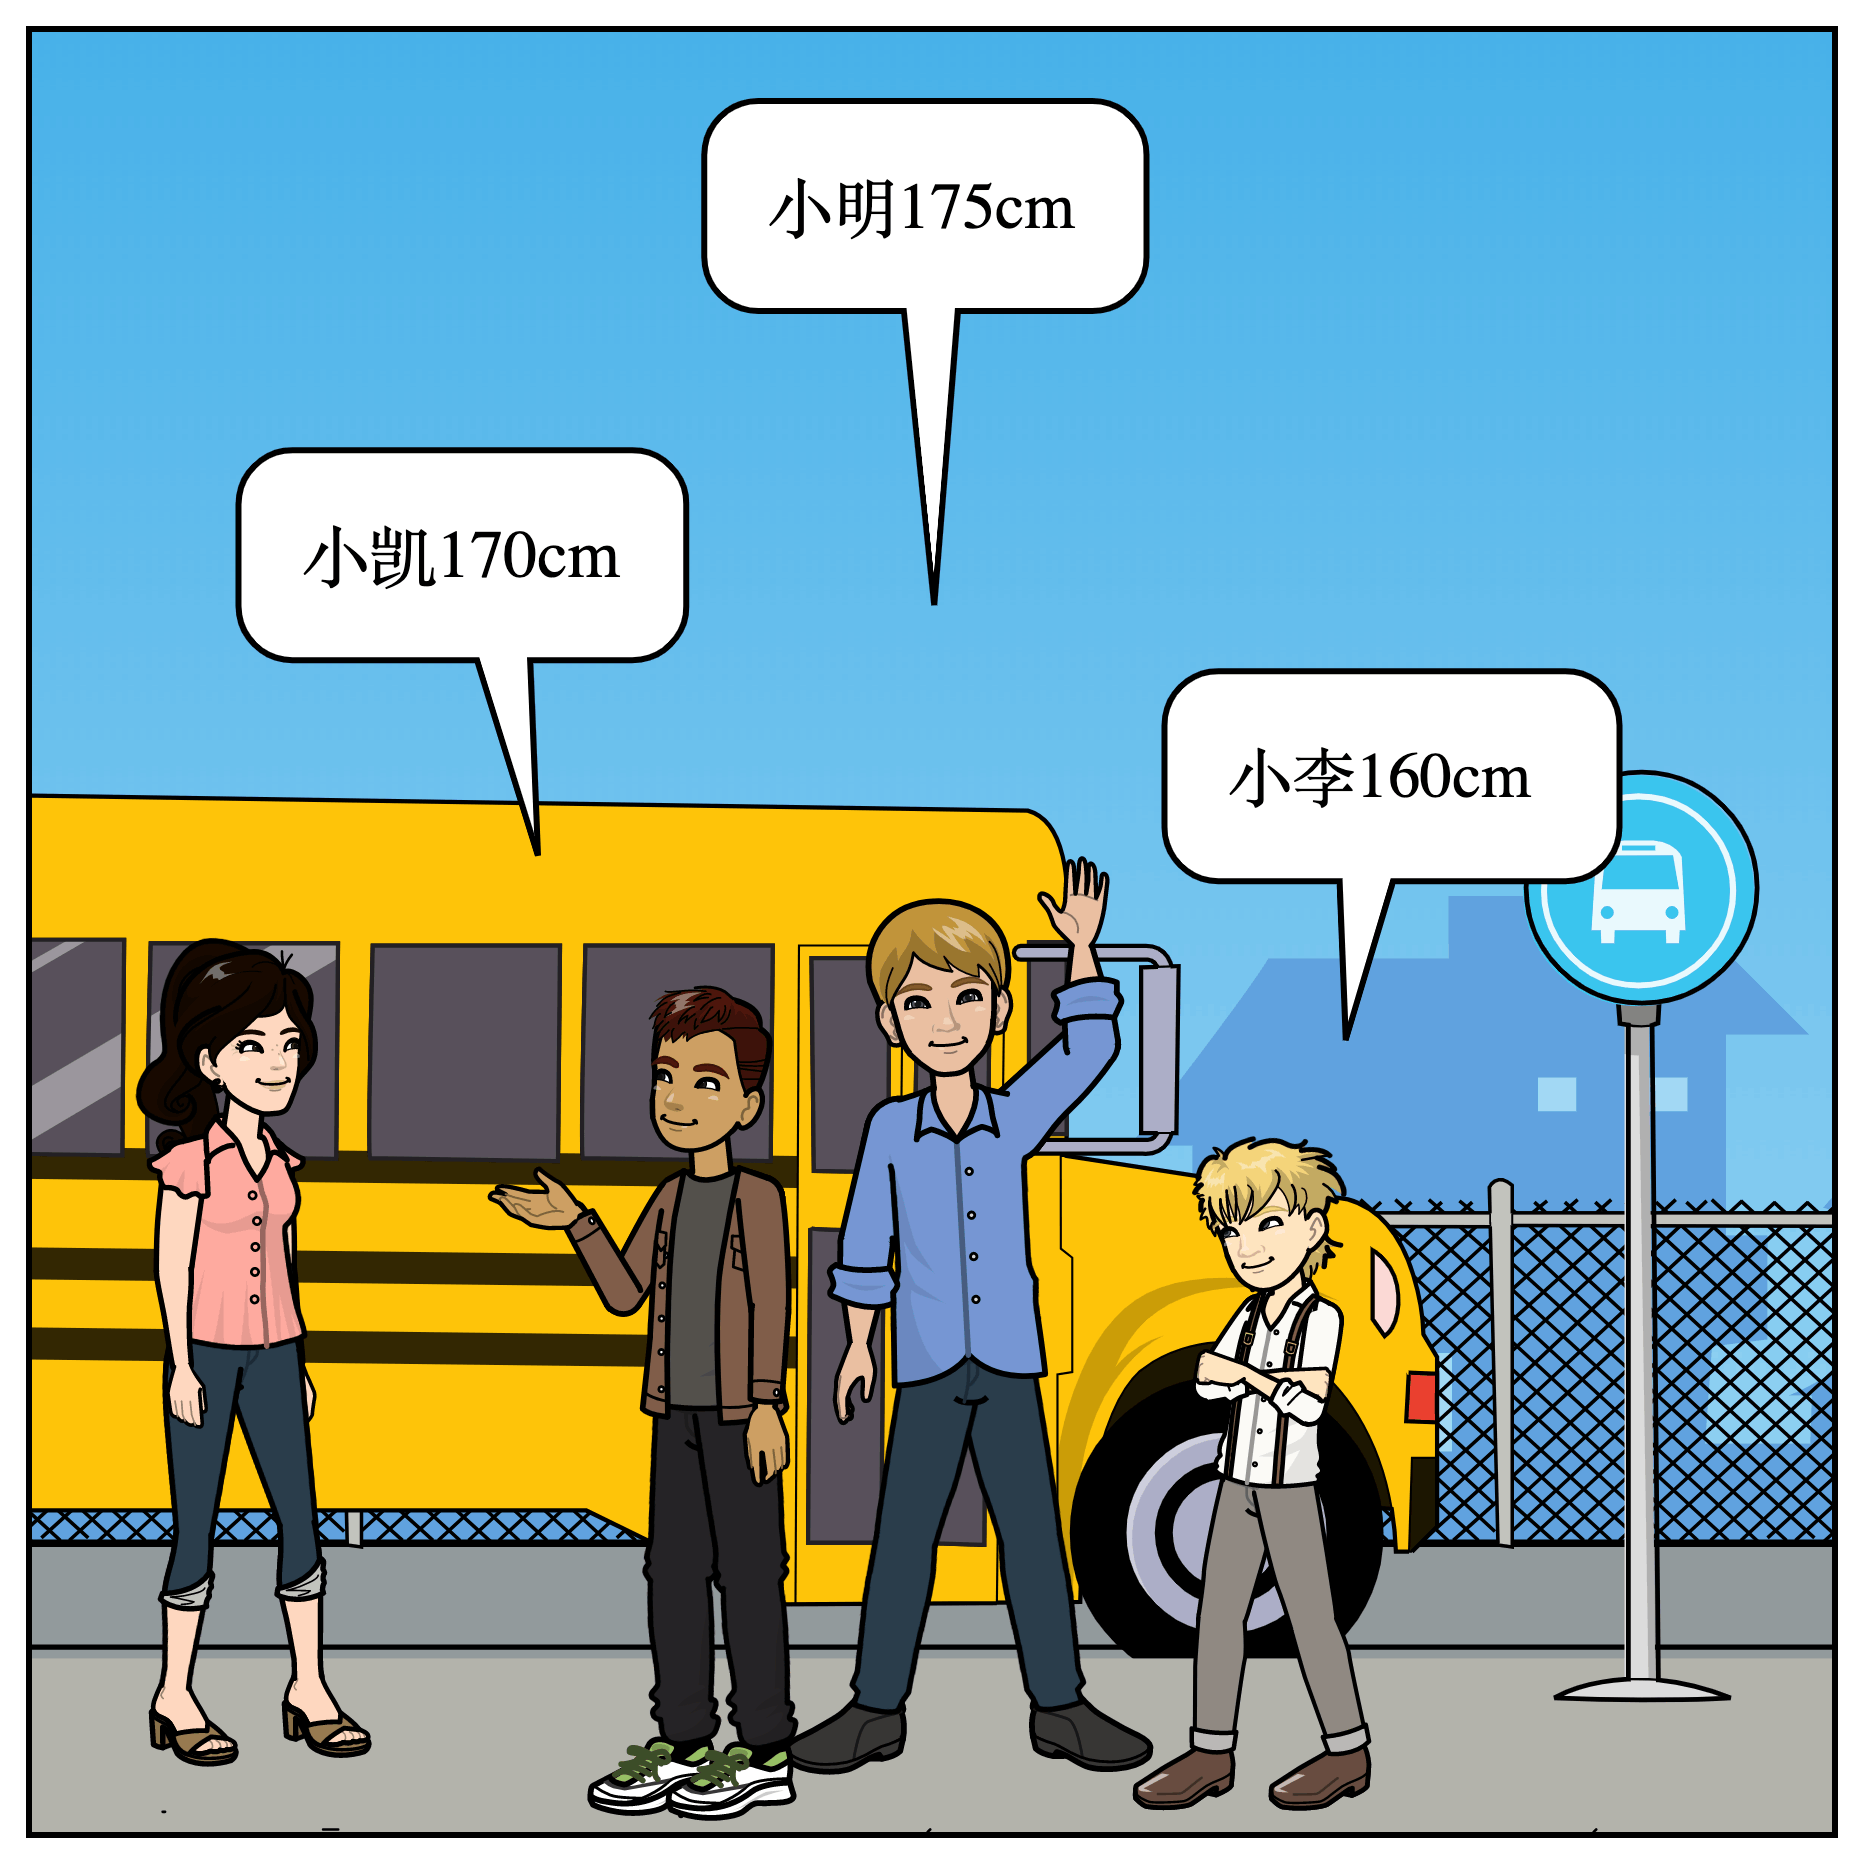

In [ ]:
Image.open(image_path)

# Run datasets

In [ ]:
human_tvj_prompt = 'Can the utterance <utterance> truly describe the picture?'

In [ ]:
instruction = '在指定语境下，判断所给句子是否可以真实地描述图片。如果可以，请输出1，否则，请输出0: '

In [ ]:
import re

def sample_predictions(model, image, prompt, n=10, max_new_tokens=10, temperature=1.0):
    outputs = []

    for _ in range(n):
        out_generator = replicate.run(
            model = model,
            input={
                "image": open(image, "rb"),
                "prompt": prompt,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,   
                "top_p": 0.9,  
                "top_k": 50,
                "do_sample": True  
            }
        )
        out_text = "".join(out_generator)

        match = re.search(r"◁\/think▷(.*?)<\|im_end\|>", out_text, re.DOTALL)
        if match:
            extracted_text = match.group(1).strip()
            outputs.append(extracted_text.split()[0])
        else:
            outputs.append(out_text.strip().split()[0])

    return outputs